In [17]:
import pandas as pd
import numpy as np
import sys
import warnings
warnings.filterwarnings('ignore')
from copy import deepcopy,copy
from datetime import datetime
import pickle
import os

# Import Machine Scientist
from importlib.machinery import SourceFileLoader
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "rguimera-machine-scientist-constrained/machinescientist_ode.py"
path = os.path.join(script_dir, relative_module_path)
ms = SourceFileLoader("ms", path).load_module()


folder_name = 'Train_test_data_lin_term_com2025_03_11-11_21_44'
with open(f'./{folder_name}/x_test.pkl', 'rb') as file:
    # A new file will be created
    x = pickle.load(file)
    
with open(f'./{folder_name}/y_test.pkl', 'rb') as file:
    # A new file will be created
    y = pickle.load(file)


f_name='Full_data_lin_term_prod_2025_03_27-06_00_44/mdl_refit_test1.pkl'
file = open(f_name,'rb')
train_bms = pickle.load(file)
print('Train model', train_bms, train_bms.E)

Train model ((_a0_ * B) * (((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) + _a6_)) -23769.1752877052


In [18]:
string = f'((((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) * (_a1_ * B)) - (_a0_ * B))'
string = f'((_a0_ * B) - (((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) * (_a0_ * B)))'
print(string)
bms_fulldata_new = ms.from_string_model(x, y,string , 1, 8, ['B'])
#bms_fulldata_new.fit_par={}
#bms_fulldata_new.x0[str(bms_fulldata_new)]=deepcopy(bms_fulldata.x0[str(bms_fulldata)])
#bms_fulldata_new.par_values=deepcopy(bms_fulldata.par_values)
#bms_fulldata_new.get_bic(reset=True,fit=False)
#bms_fulldata_new.get_energy(reset=True)
print('New Train (recovered pars)',bms_fulldata_new.E,bms_fulldata_new.EB,bms_fulldata_new.EP)
#bms_fulldata_new=deepcopy(bms_fulldata)
print(bms_fulldata_new.E)

bms_fulldata_new.par_values = train_bms.par_values
bms_fulldata_new.fit_par={}
bms_fulldata_new.get_bic(reset=True,fit=True)
bms_fulldata_new.get_energy(reset=True)

print('Refit energy:',bms_fulldata_new.E)

((_a0_ * B) - (((exp((B * _a2_)) * (_a4_ * B)) ** (B ** 3)) * (_a0_ * B)))
Model summary
Par_values: {'H3': {'_a0_': 0.02362241781502598, '_a2_': -16765.760612564274, '_a4_': -7.434050579851003e-309}, 'D6': {'_a0_': 60.38296980828347, '_a2_': -1.7649887566272058, '_a4_': 4.79632820187076}, 'C7': {'_a0_': 0.02640202654507961, '_a2_': -5.332676536207305, '_a4_': 1.21757602736e-313}, 'F3': {'_a0_': 26.16207892695443, '_a2_': -1.6790959905116387, '_a4_': 4.5575098012276625}, 'B11': {'_a0_': 27.88498853213862, '_a2_': -1.8811481753261368, '_a4_': 5.102270744775512}, 'B12': {'_a0_': 8.541827712622293, '_a2_': -1.0845156797957964, '_a4_': 2.942788579200408}, 'E12': {'_a0_': 48.992168484078526, '_a2_': -1.870323725065163, '_a4_': 5.08148830186}, 'A3': {'_a0_': 43.225697283951305, '_a2_': -1.668254510097179, '_a4_': 4.533197346366714}, 'G9': {'_a0_': 50.58127873334873, '_a2_': -1.9406641419223125, '_a4_': 5.527525134742605}, 'C11': {'_a0_': 47.497784491132904, '_a2_': -1.6183076675208201, '_a4_

In [31]:
old_par_values=deepcopy(bms_fulldata_new.par_values)
old_cols=list(old_par_values.keys())


print('Energy before refitting:',bms_fulldata_new.E)
old_energy = deepcopy(bms_fulldata_new.E)


f_name=f'mdl_mod_model2_test.pkl'
file = open(f_name,'wb')
pickle.dump(bms_fulldata_new,file)
file.close()


for o_col in old_cols:
    for n_col in old_cols:
        #print(o_col,n_col)
        #test_model=deepcopy(bms_fulldata_new)
        bms_fulldata_new.fit_par={}
        p=deepcopy(bms_fulldata_new.par_values[n_col])
        bms_fulldata_new.par_values[n_col]=deepcopy(old_par_values[o_col])
        bms_fulldata_new.get_bic(reset=True,fit=True)
        bms_fulldata_new.get_energy(reset=True)
        if bms_fulldata_new.E<old_energy and not np.isinf(float(bms_fulldata_new.E)):
            print('Better fit. Update model.',bms_fulldata_new.E)
            old_energy=deepcopy(bms_fulldata_new.E)
            file = open(f_name,'wb')
            pickle.dump(bms_fulldata_new,file)
            file.close()
        else:
            # Not improving energy. Setting previorus parameters
            bms_fulldata_new.par_values[n_col]=deepcopy(p)

Energy before refitting: -22133.0677910160
Better fit. Update model. -22133.0677921361
Better fit. Update model. -22133.0677944476
Better fit. Update model. -22133.0677944625
Better fit. Update model. -22133.0677945073
Better fit. Update model. -22133.0677947671
Better fit. Update model. -22133.0677948887
Better fit. Update model. -22133.0677949056
Better fit. Update model. -22133.0677949071
Better fit. Update model. -22133.0677949081
Better fit. Update model. -22133.0677949084
Better fit. Update model. -22133.0677949215
Better fit. Update model. -22133.0677952725
Better fit. Update model. -22133.0677952767
Better fit. Update model. -22133.0678091759
Better fit. Update model. -22133.0678091787
Better fit. Update model. -22133.0678091869
Better fit. Update model. -22133.0678091915
Better fit. Update model. -22133.0678092690
Better fit. Update model. -22133.0678093094
Better fit. Update model. -22133.0678093237
Better fit. Update model. -22133.0678093250
Better fit. Update model. -22133.

KeyboardInterrupt: 

In [35]:
for key,item in bms_fulldata_new.par_values.items():
    #if item['_a0_']<1.:
    print(key)
    bms_fulldata_new.par_values[key]=deepcopy(bms_fulldata_new.par_values['R.S.6 D-Arabitol, 0.3%_6'])
    bms_fulldata_new.x0[str(bms_fulldata_new)][key]=bms_fulldata_new.x[key].B.to_numpy()[0]
bms_fulldata_new.fit_par={}
bms_fulldata_new.get_bic(reset=True,fit=True)
bms_fulldata_new.get_energy(reset=True)

print('Better fit. Update model.',bms_fulldata_new.E)          

H3
D6
C7
F3
B11
B12
E12
A3
G9
C11
D5
C5
D8
A6
B4
R.S.6 4 Hydroxy-Phenylacetate, 0.3%_6
R.S.6 D-Trehalose, 0.3%_6
R.S.6 D-Arabitol, 0.3%_6
R.S.6 Alpha-D-Lactose, 0.3%_6
R.S.6 Malate, 0.3%_6
R.S.6 D-Cellubiose, 0.3%_6
R.S.6 Allantoin, 0.2%_6
R.S.6 D-Raffinose, 0.3%_6
R.S.6 N-Acetyl-D-Glucosamine, 0.2%_6
R.S.6 D-Fructose, 0.3%_6
R.S.6 D-Xylose, 0.3%_6
R.S.6 Citrate, 0.3%_6
R.S.6 Adonitol, 0.3%_6
R.S.6 D-Glutamate, 0.2%_6
R.S.6 L-Arginine, 0.2%_6
R.S.6 Lactate, 0.3%_6
R.S.6 L-Alanine, 0.3%_6
R.S.6 Sucrose, 0.3%_6
R.S.6 D-Glucose, 0.3%_6
R.S.6 Adenosine, 0.2%.1_6
D Glucose 6 PO4_10
Adenosine_10
D Glucose_10
Cytidine_10
D Ribose_10
D- Trehalose_10
Inosine_10
Glycerol_10
L Glutathione_10
D Fructose_10
D Serine_10
Alpha D Melebiose_10
R.S.12 Lactulose, 0.3%_12
R.S.12 Glycerol, 0.3%_12
R.S.12 Myo-Inositol, 0.3%_12
R.S.12 D-Galactose, 0.3%_12
R.S.12 Dulcitol, 0.3%_12
R.S.12 Alpha-D-Glucose, 0.3%_12
R.S.12 D-Fructose, 0.3%_12
R.S.12 Citrate, 0.3%_12
R.S.12 D-Mannose, 0.3%_12
R.S.12 D-Salicin, 0.3

H3


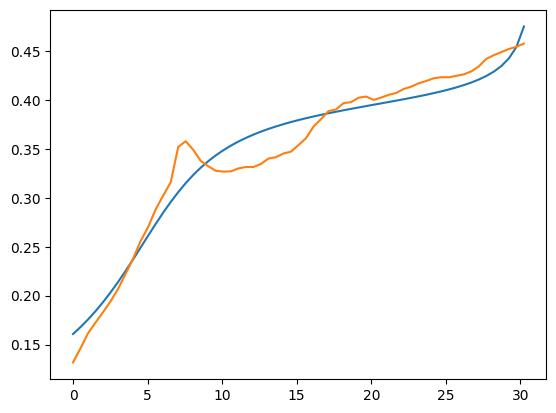

D6


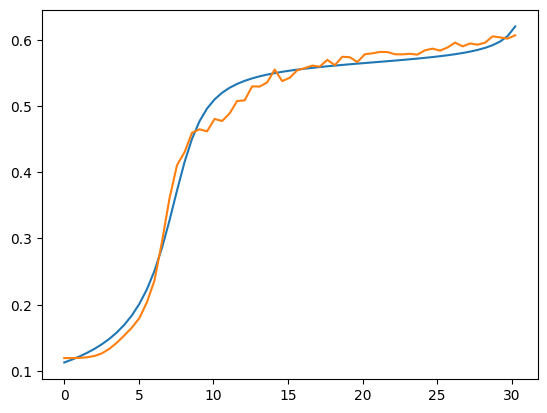

C7


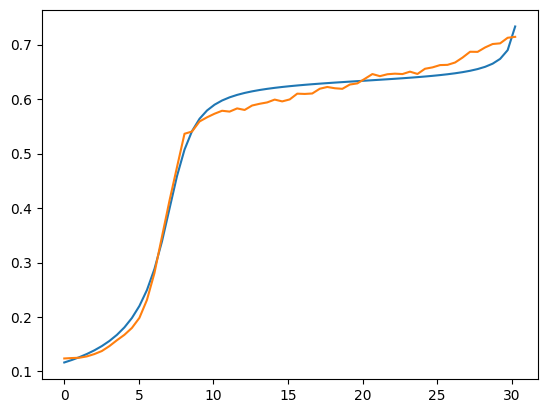

F3


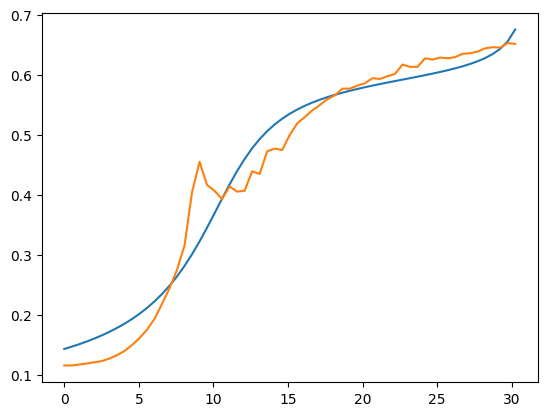

B11


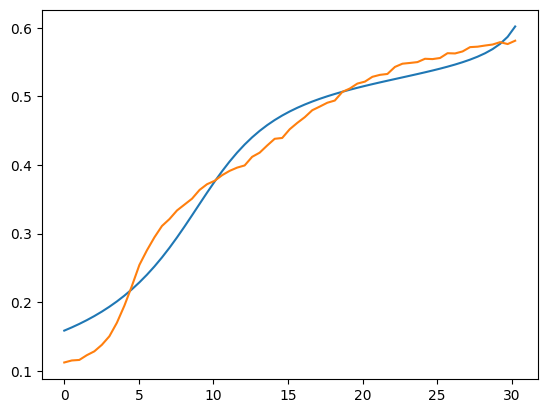

B12


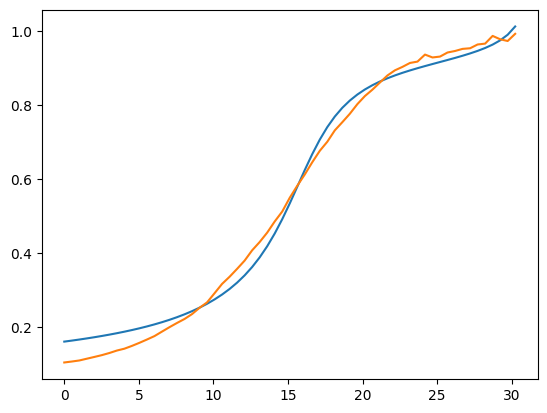

E12


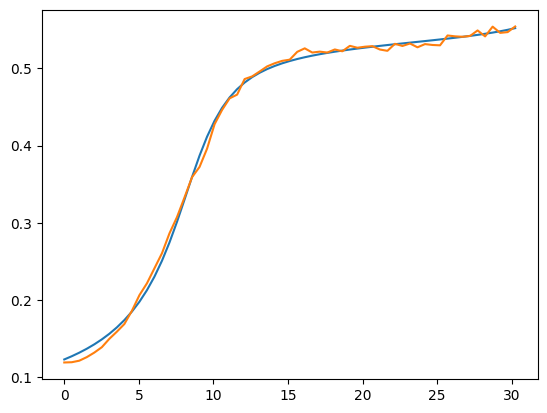

A3


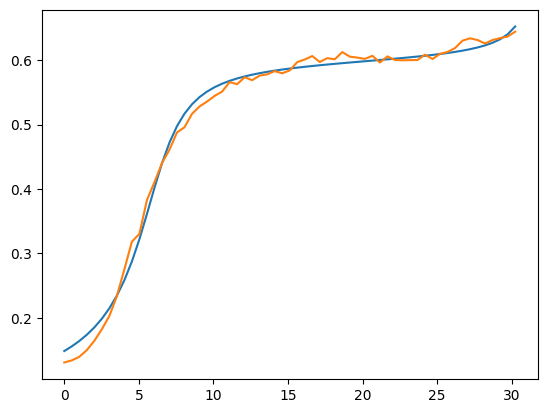

G9


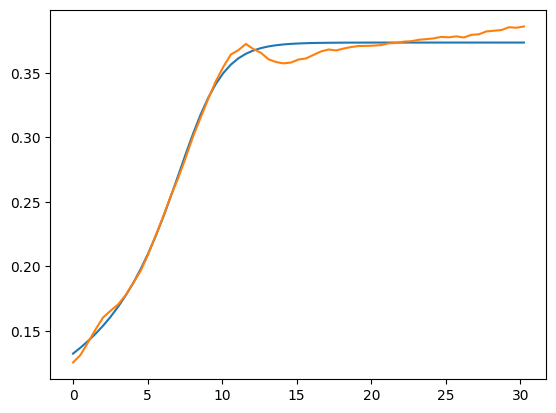

C11


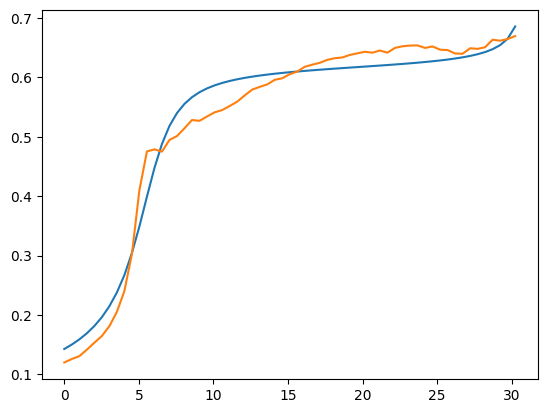

D5


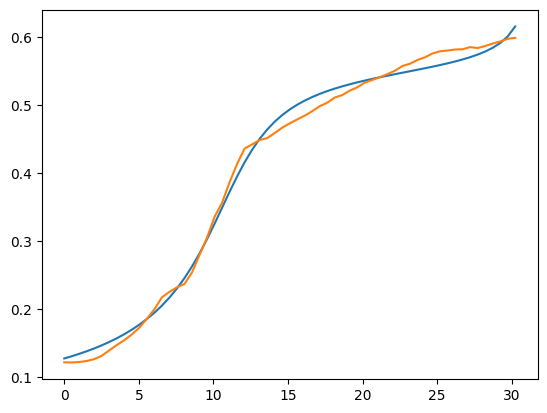

C5


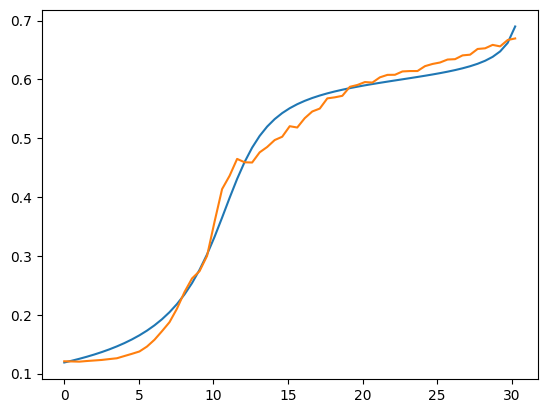

D8


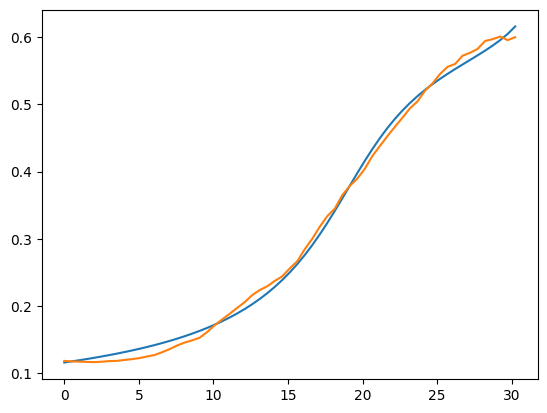

A6


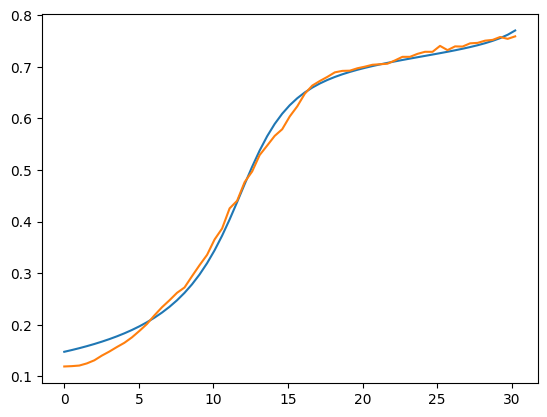

B4


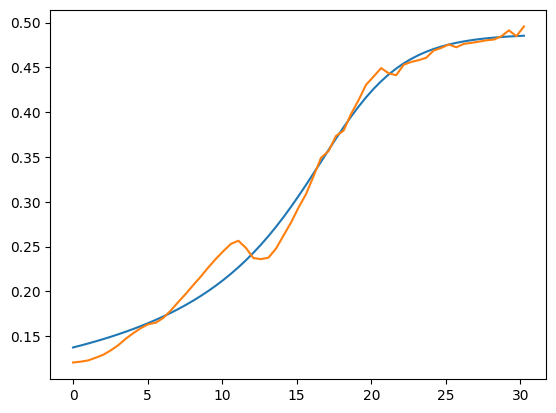

R.S.6 4 Hydroxy-Phenylacetate, 0.3%_6


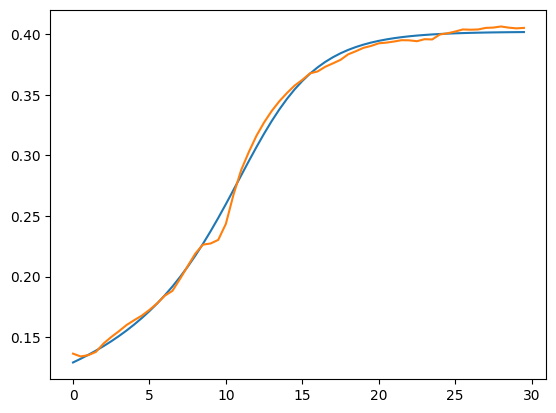

R.S.6 D-Trehalose, 0.3%_6


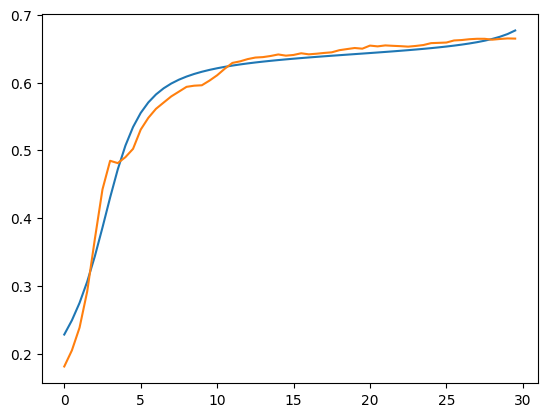

R.S.6 D-Arabitol, 0.3%_6


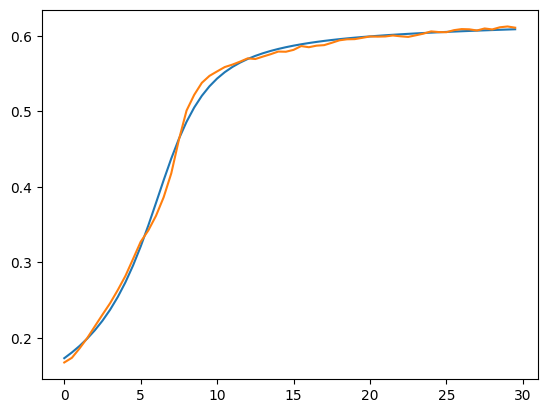

R.S.6 Alpha-D-Lactose, 0.3%_6


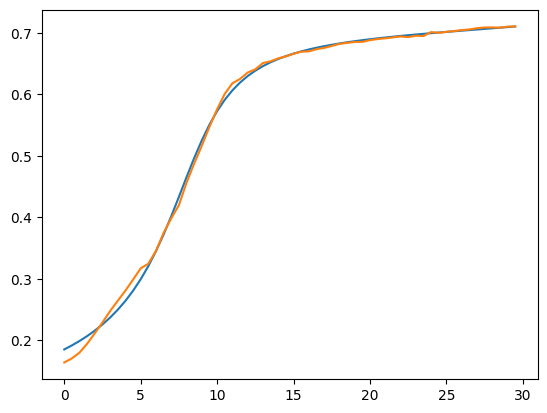

R.S.6 Malate, 0.3%_6


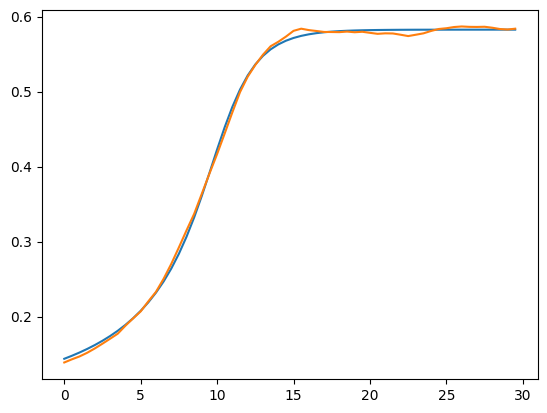

R.S.6 D-Cellubiose, 0.3%_6


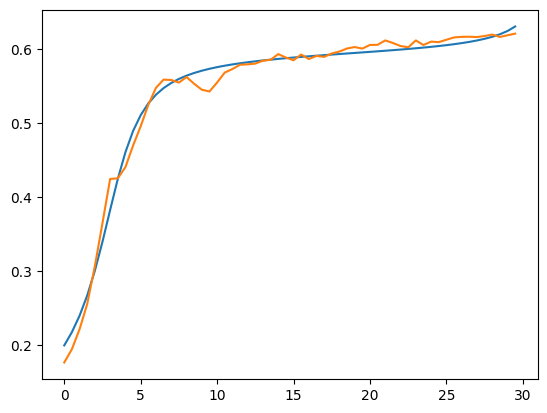

R.S.6 Allantoin, 0.2%_6


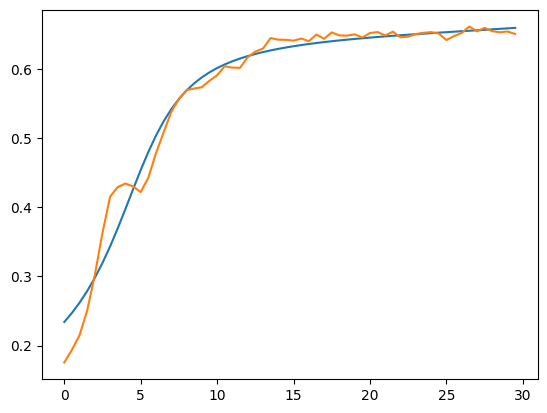

R.S.6 D-Raffinose, 0.3%_6


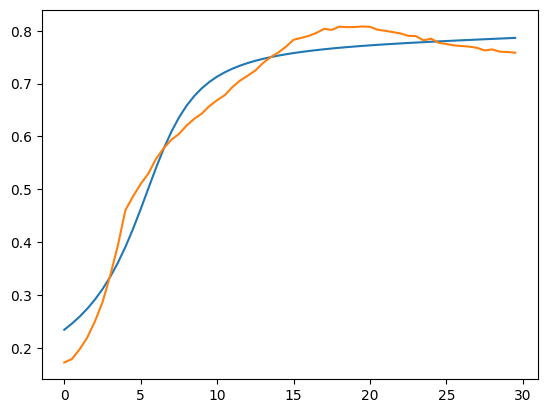

R.S.6 N-Acetyl-D-Glucosamine, 0.2%_6


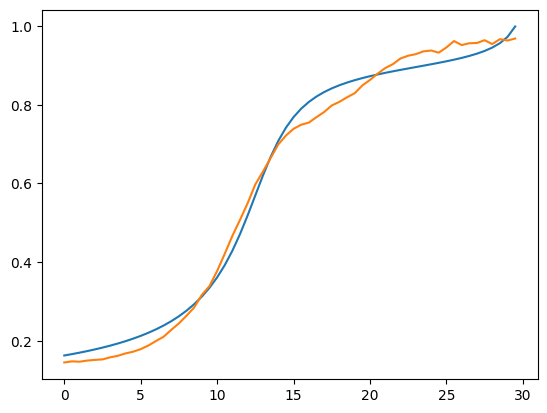

R.S.6 D-Fructose, 0.3%_6


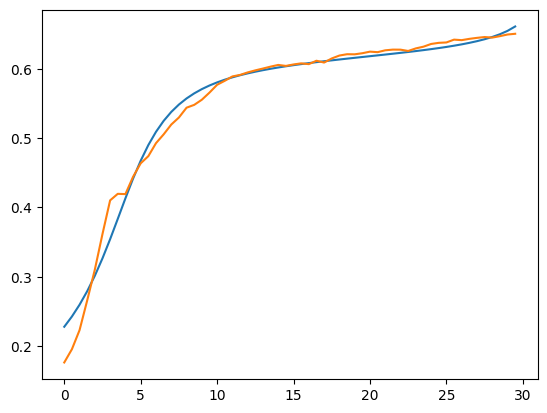

R.S.6 D-Xylose, 0.3%_6


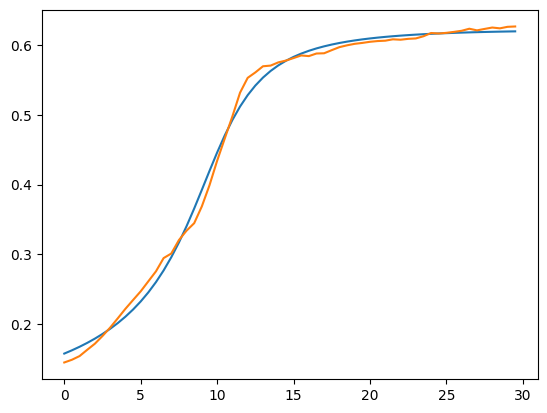

R.S.6 Citrate, 0.3%_6


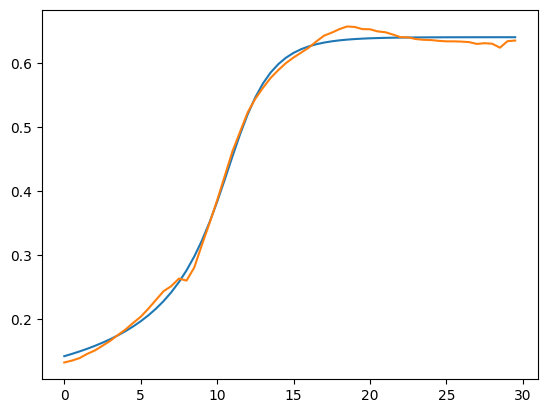

R.S.6 Adonitol, 0.3%_6


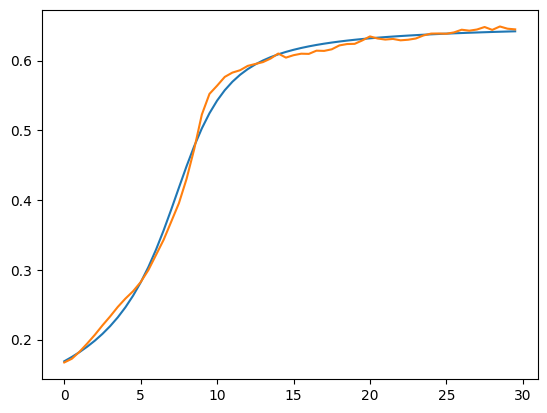

R.S.6 D-Glutamate, 0.2%_6


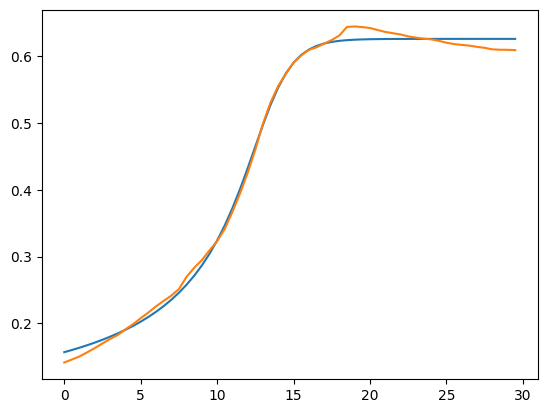

R.S.6 L-Arginine, 0.2%_6


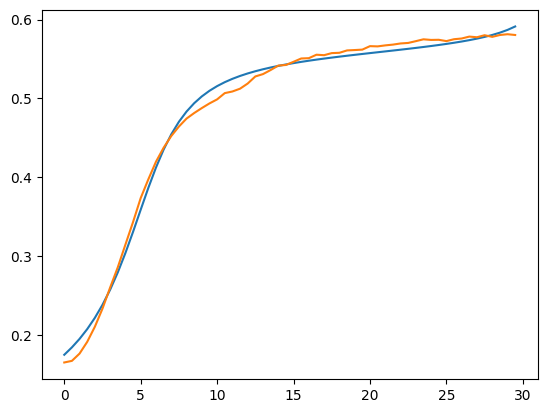

R.S.6 Lactate, 0.3%_6


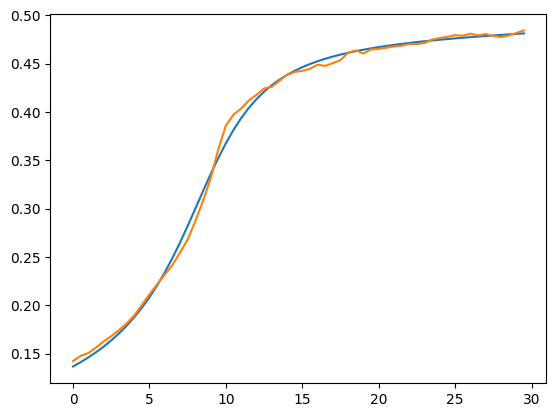

R.S.6 L-Alanine, 0.3%_6


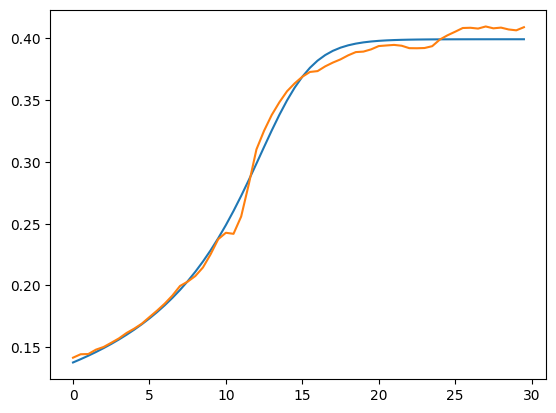

R.S.6 Sucrose, 0.3%_6


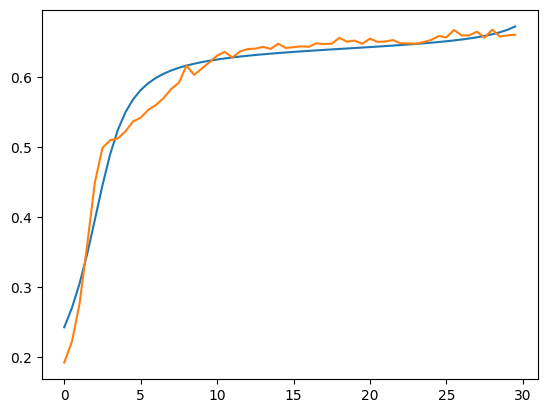

R.S.6 D-Glucose, 0.3%_6


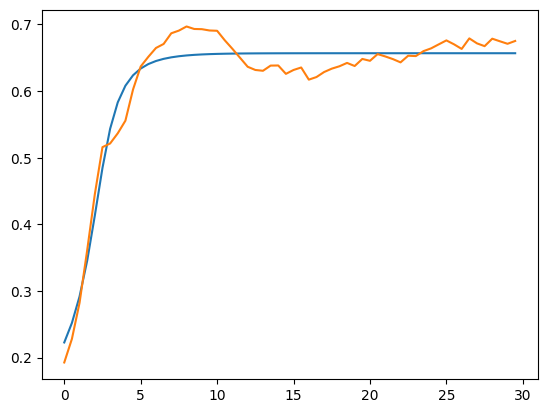

R.S.6 Adenosine, 0.2%.1_6


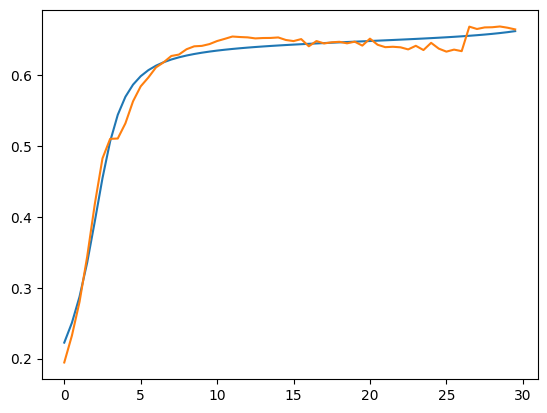

D Glucose 6 PO4_10


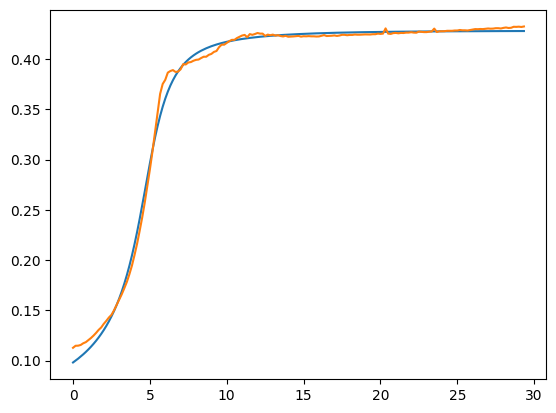

Adenosine_10


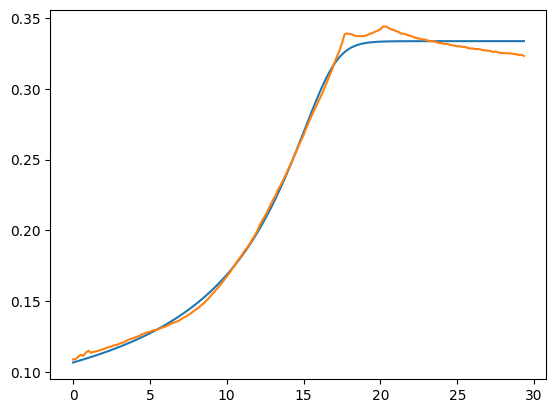

D Glucose_10


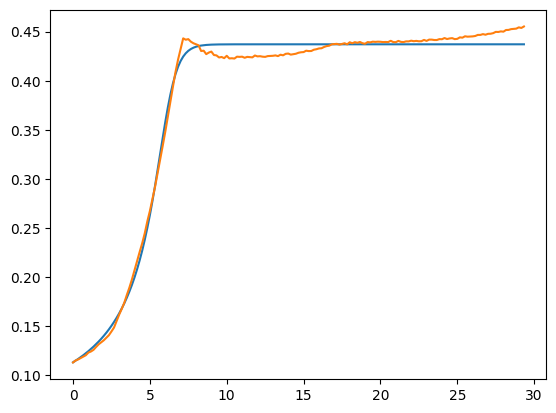

Cytidine_10


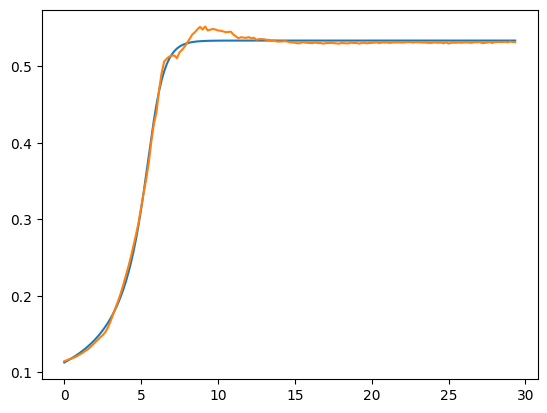

D Ribose_10


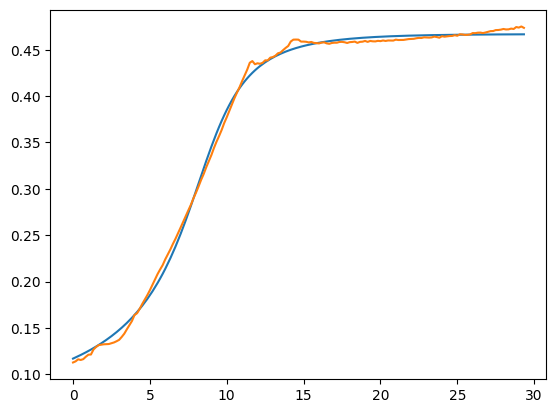

D- Trehalose_10


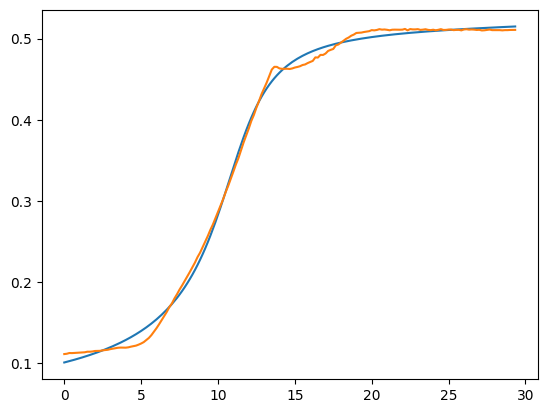

Inosine_10


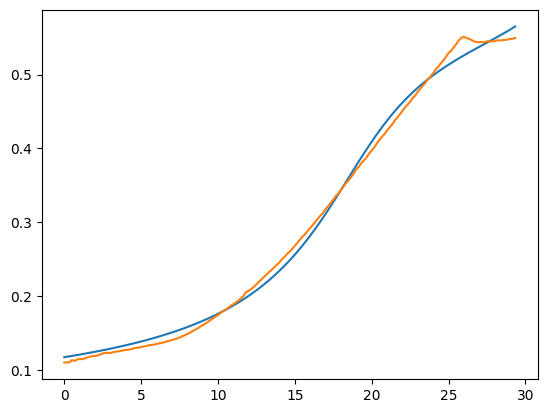

Glycerol_10


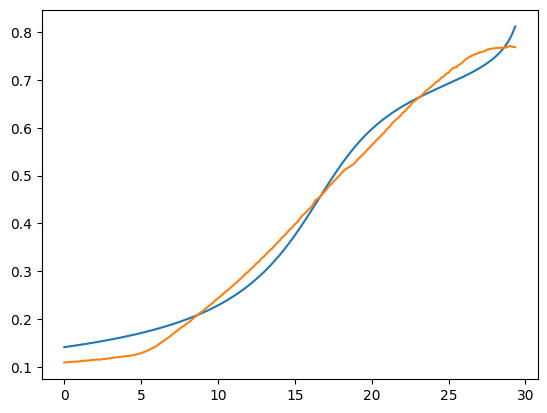

L Glutathione_10


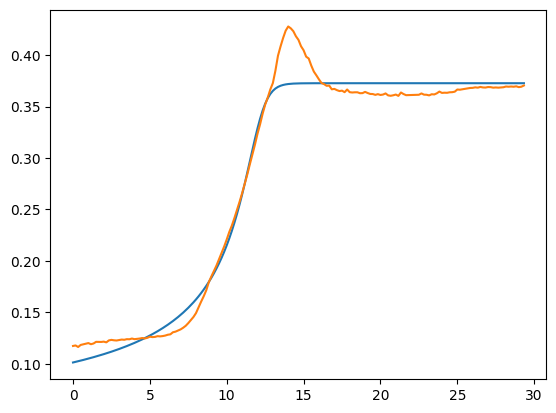

D Fructose_10


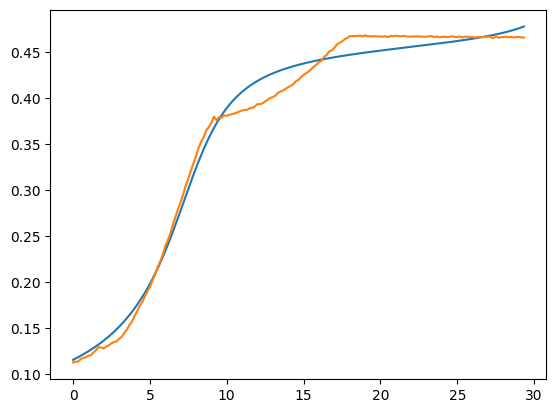

D Serine_10


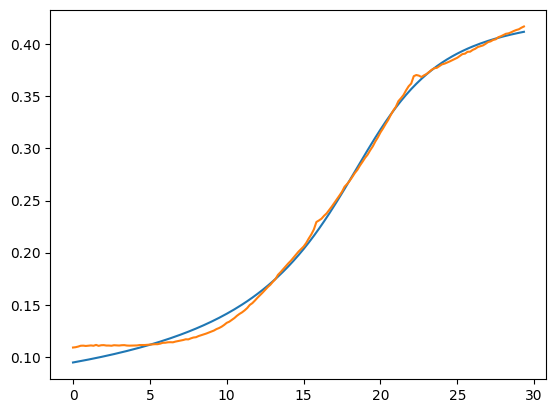

Alpha D Melebiose_10


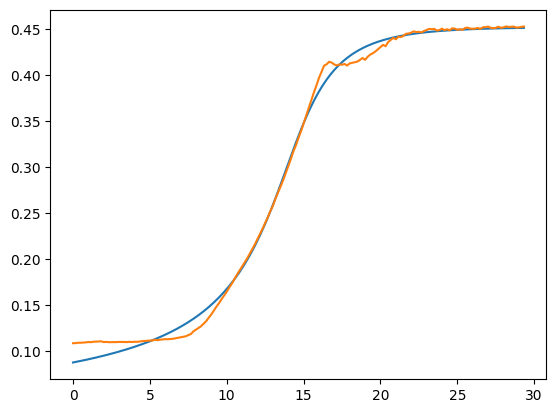

R.S.12 Lactulose, 0.3%_12


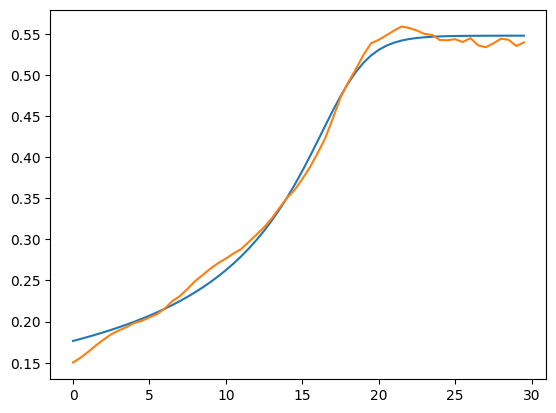

R.S.12 Glycerol, 0.3%_12


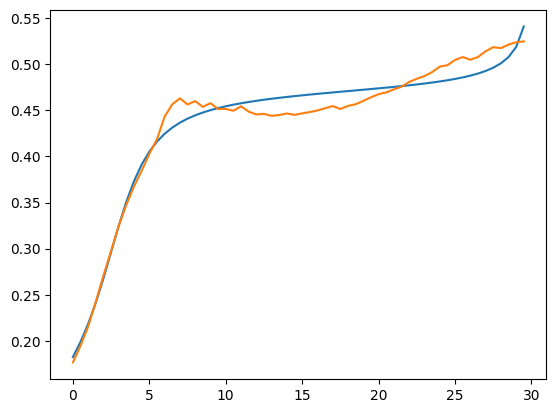

R.S.12 Myo-Inositol, 0.3%_12


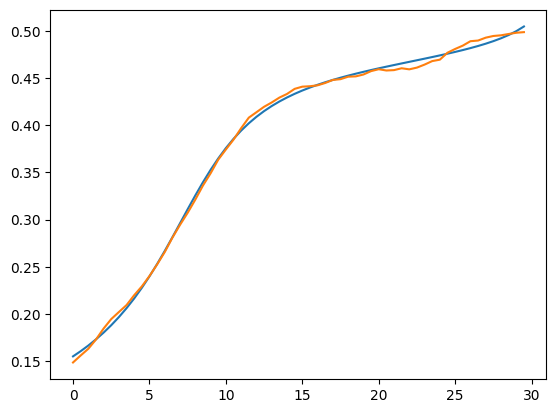

R.S.12 D-Galactose, 0.3%_12


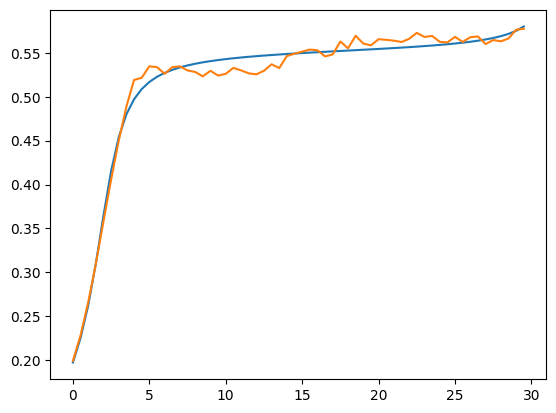

R.S.12 Dulcitol, 0.3%_12


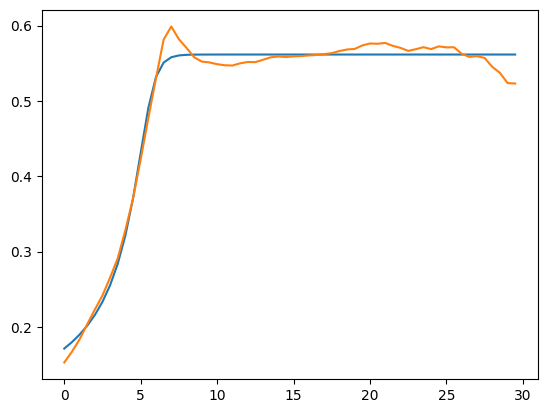

R.S.12 Alpha-D-Glucose, 0.3%_12


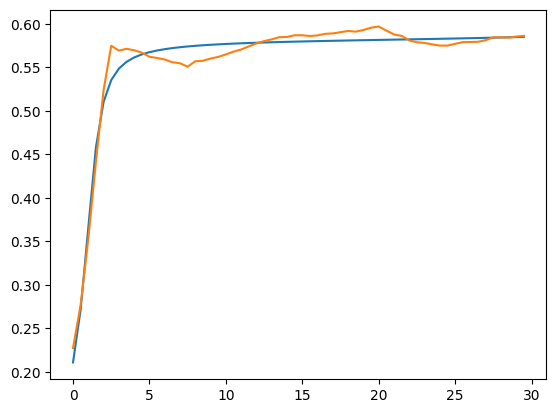

R.S.12 D-Fructose, 0.3%_12


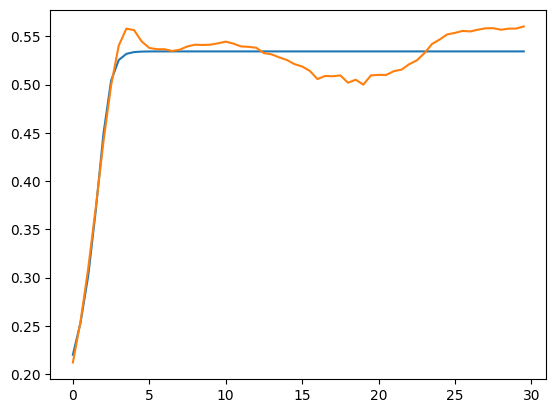

R.S.12 Citrate, 0.3%_12


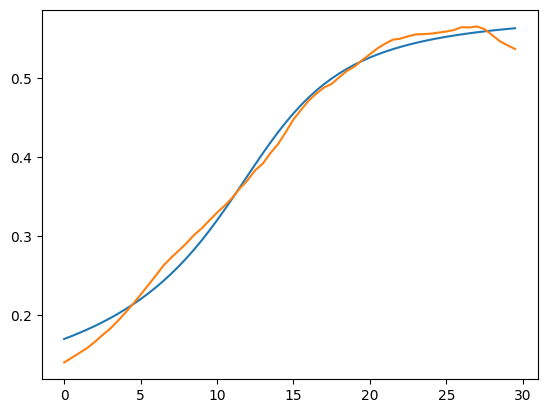

R.S.12 D-Mannose, 0.3%_12


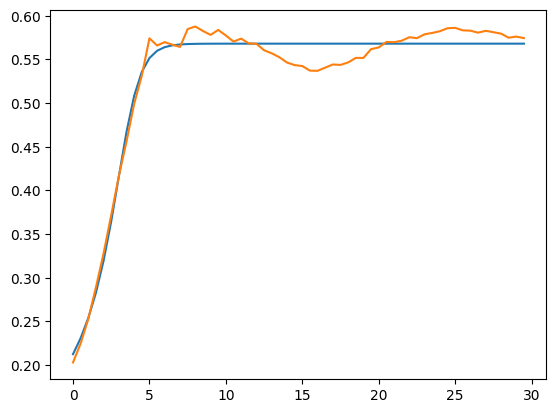

R.S.12 D-Salicin, 0.3%_12


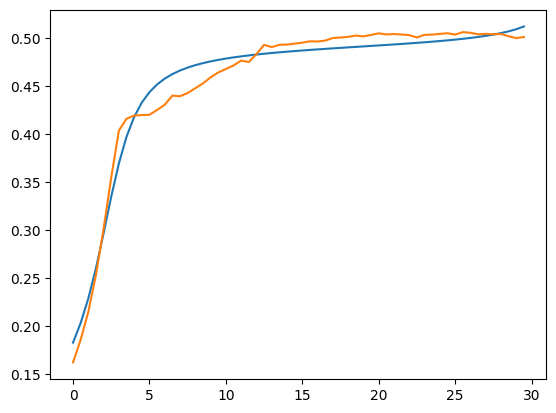

R.S.12 D-Cellubiose, 0.3%_12


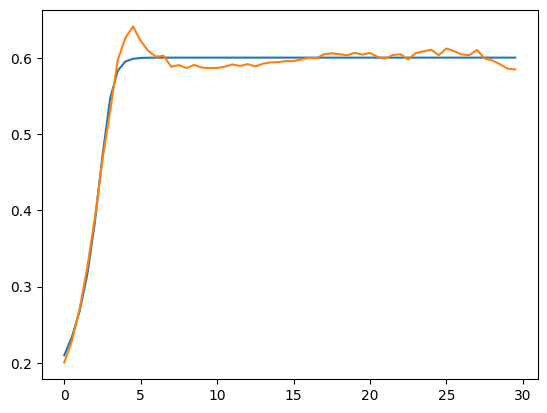

R.S.12 Adonitol, 0.3%_12


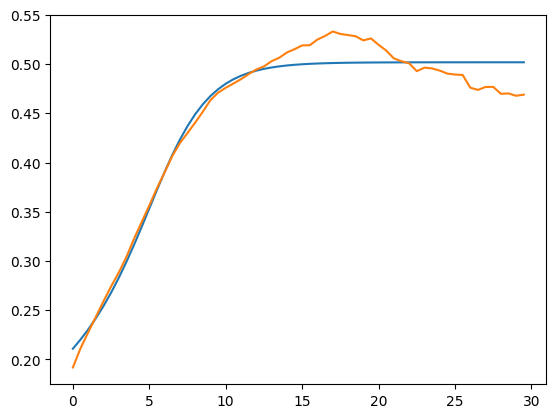

R.S.12 D-Glucose-6-phosphate, 0.3%_12


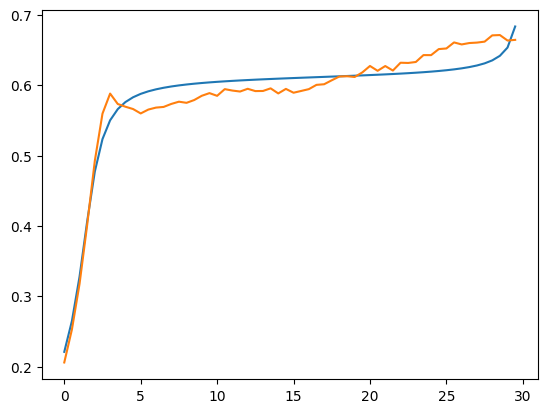

R.S.12 D-Arabitol, 0.3%_12


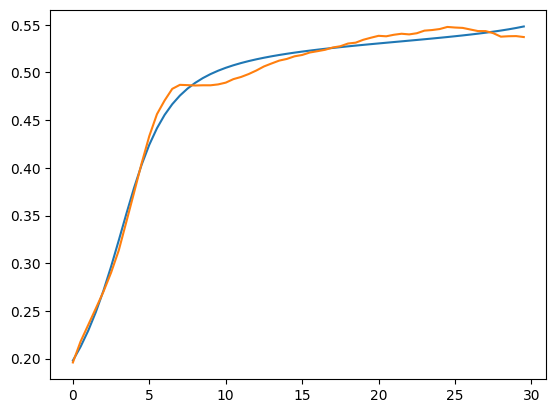

R.S.12 D-Trehalose, 0.3%_12


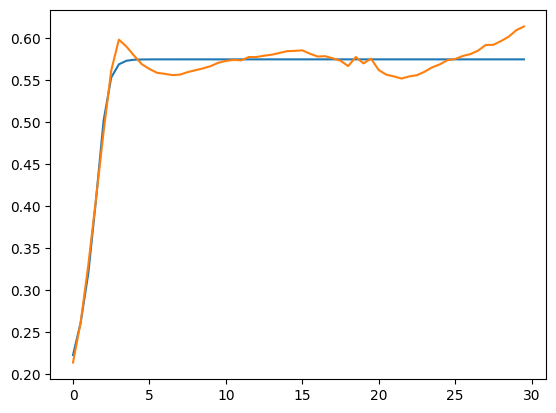

R.S.12 L-Arabinose, 0.3%_12


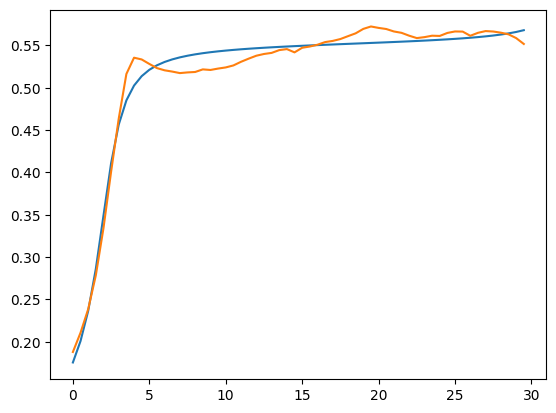

R.S.12 D-Ribose, 0.3%_12


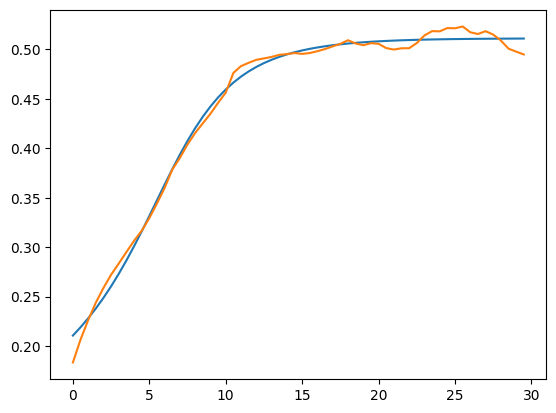

R.S.12 Alpha-D-Melebiose, 0.3%_12


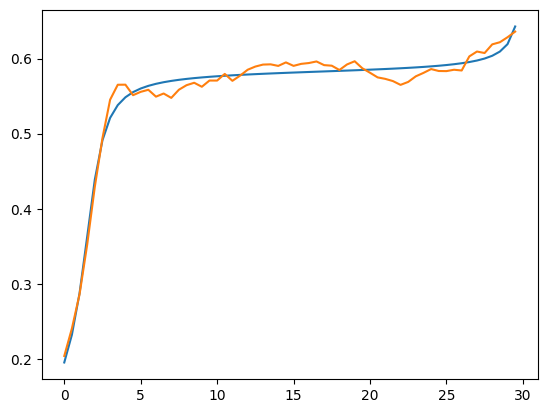

R.S.12 L-Fucose, 0.3%_12


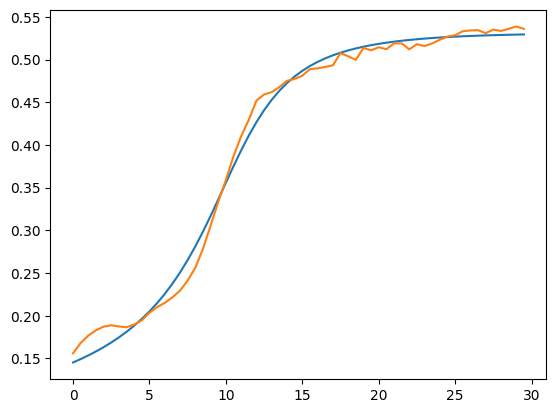

R.S.12 Inosine, 0.3%_12


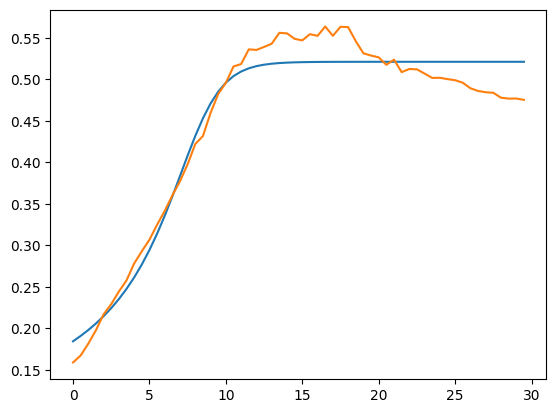

R.S.12 Sucrose, 0.3%_12


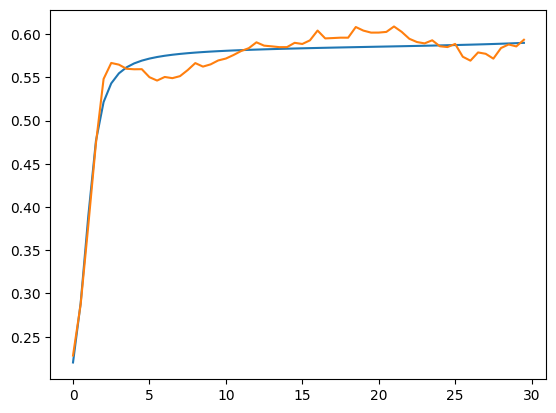

R.S.12 D-Xylose, 0.3%_12


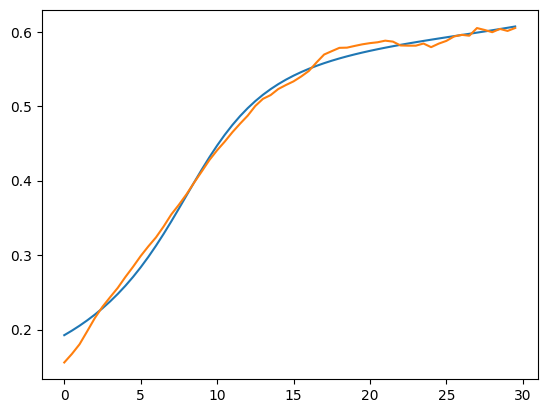

R.S.12 Alpha-D-Lactose, 0.3%_12


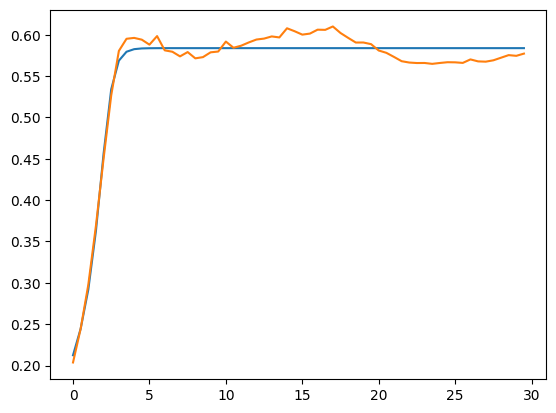

R.S.12 D-Raffinose, 0.3%_12


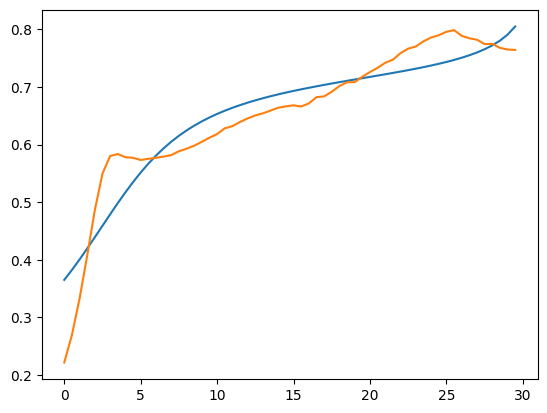

R.S.12 L-Glutamine, 0.3%_12


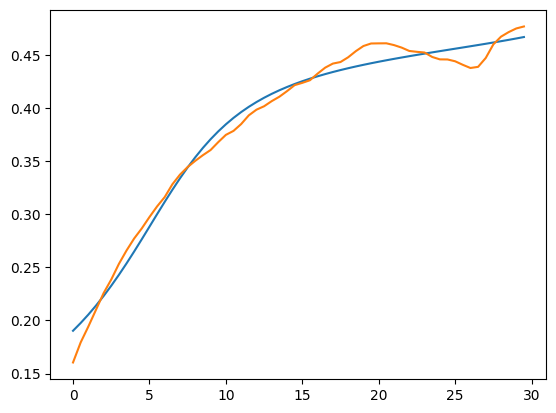

R.S.12 L-Rhamnose, 0.3%_12


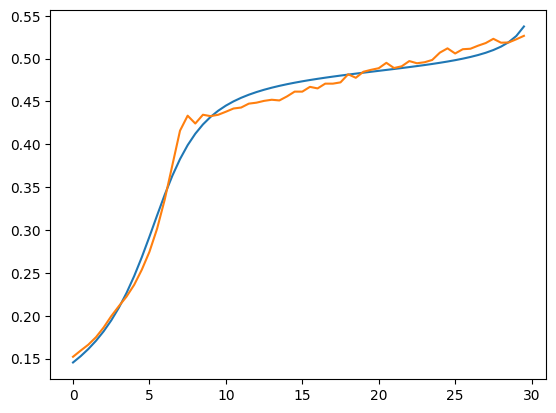

R.S.12 D-Glucosamine, 0.3%_12


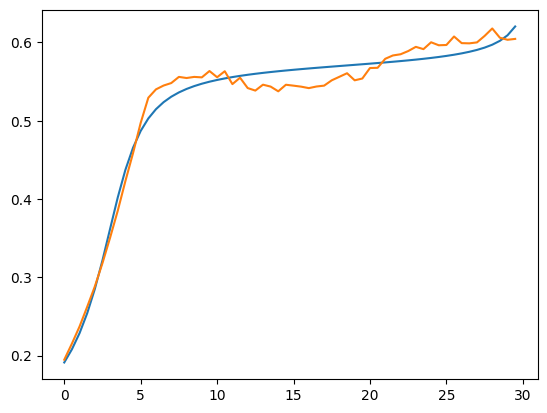

R.S.12 D-Glutamate, 0.2%_12


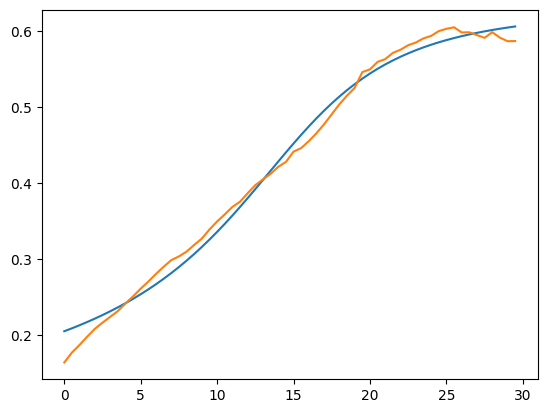

R.S.12 Cytidine, 0.3%_12


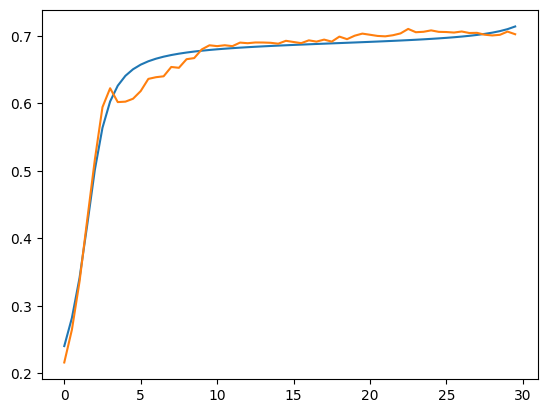

R.S.12 Adenosine, 0.2%.1_12


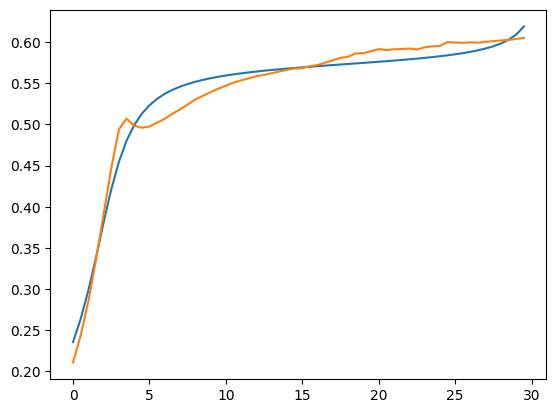

R.S.12 L-Arginine, 0.2%_12


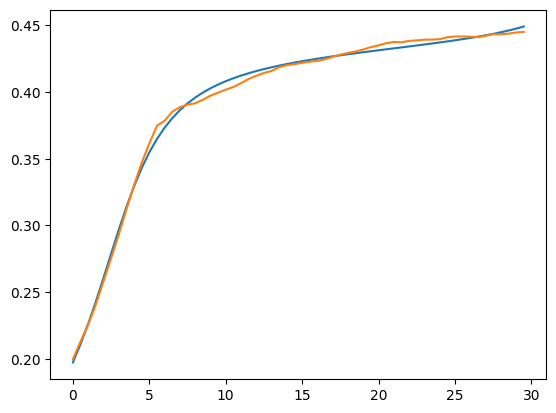

R.S.12 Guanidine, 0.3%_12


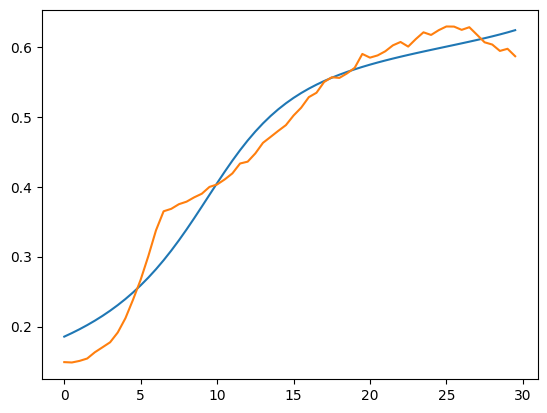

R.S.12 L-Glutathione, 0.2%_12


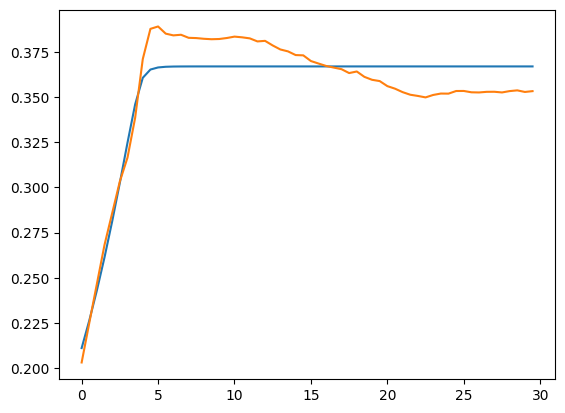

R.S.12 Allantoin, 0.2%_12


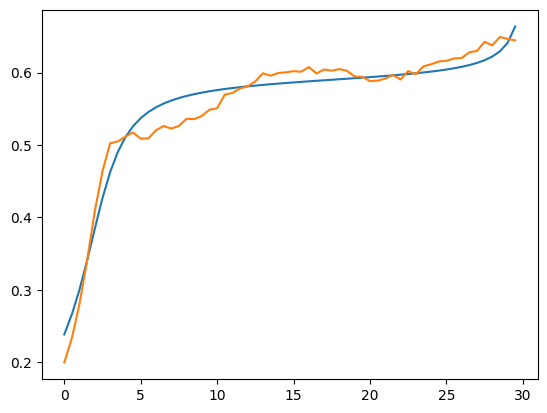

R.S.12 Cytosine, 0.2%_12


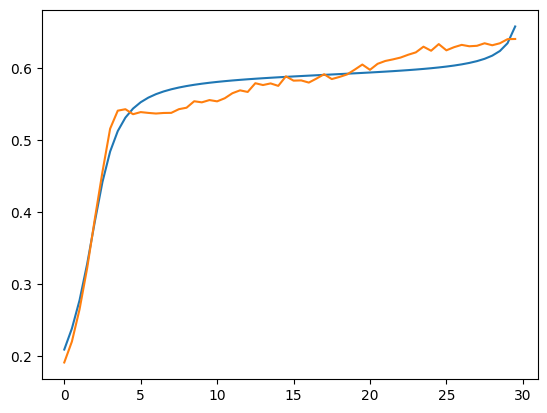

R.S.18 D-Mannose_18


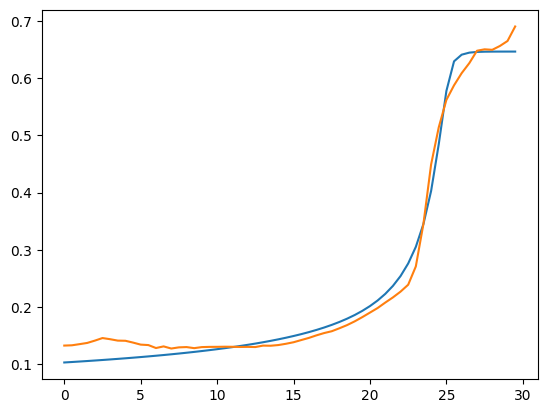

R.S.18 Thymine_18


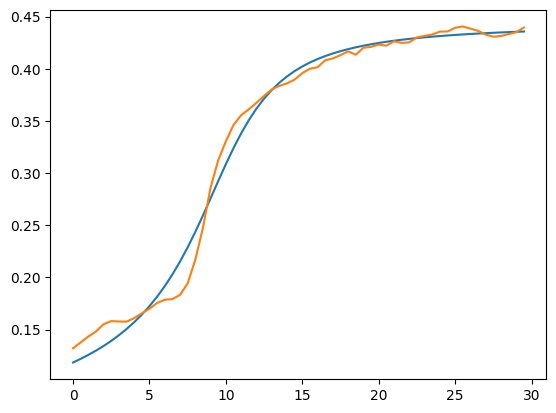

R.S.18 Citrate_18


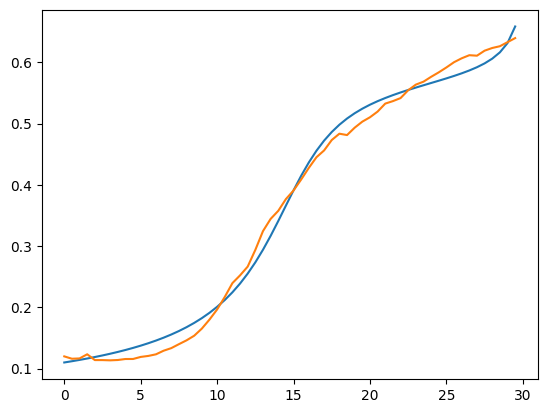

R.S.18 Thiourea_18


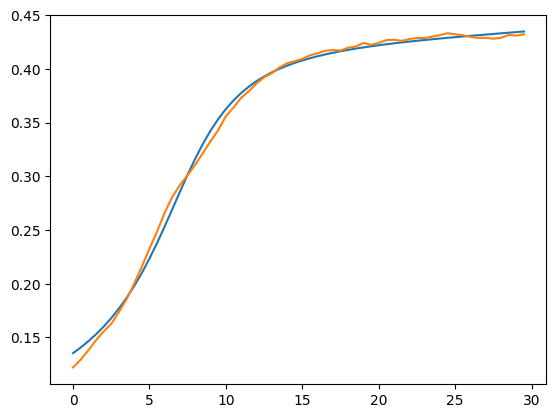

R.S.18 D-Glucose_18


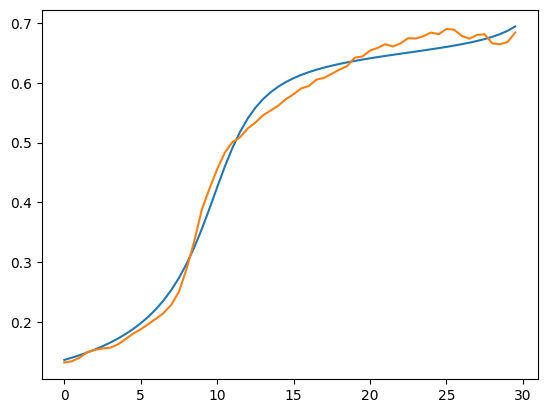

R.S.18 Thymidine_18


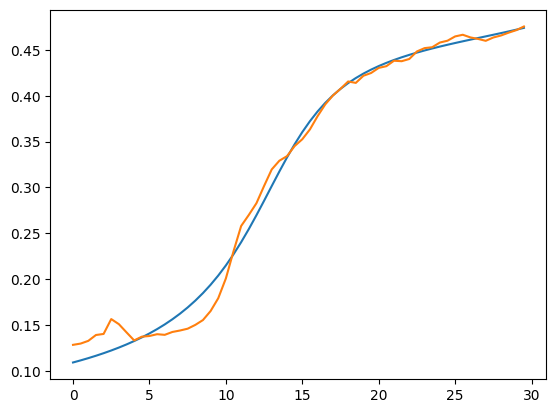

R.S.18 L-Pyro-Glutamate.1_18


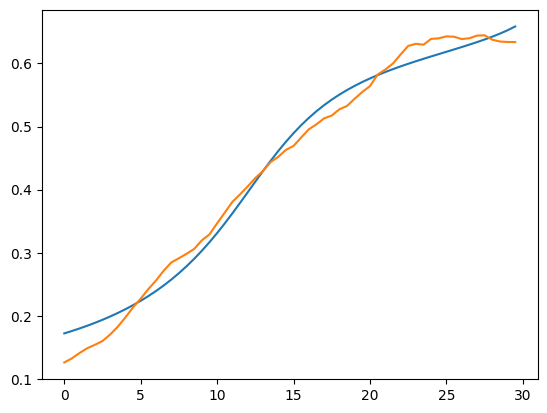

R.S.18 Biuret_18


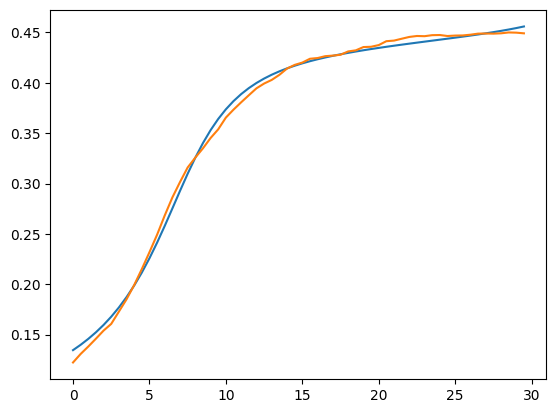

R.S.18 Inosine_18


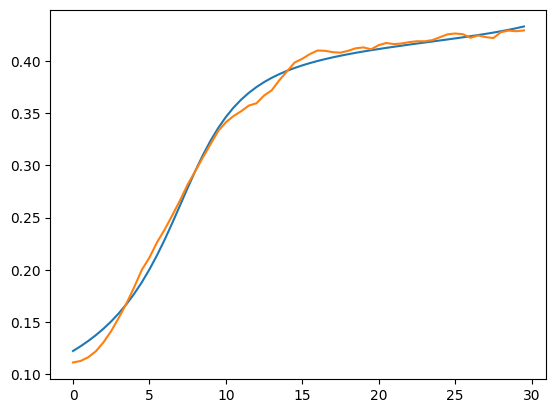

R.S.18 Sucrose_18


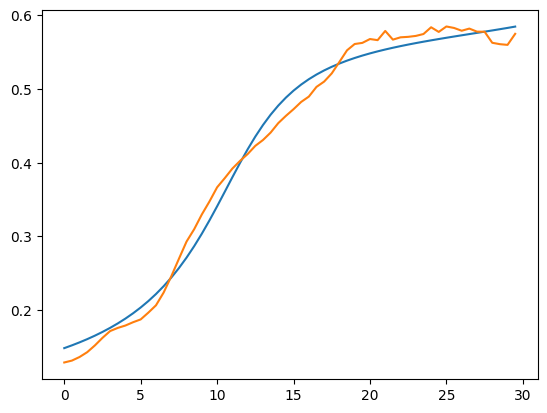

R.S.18 Nitrogen Neg. Control_18


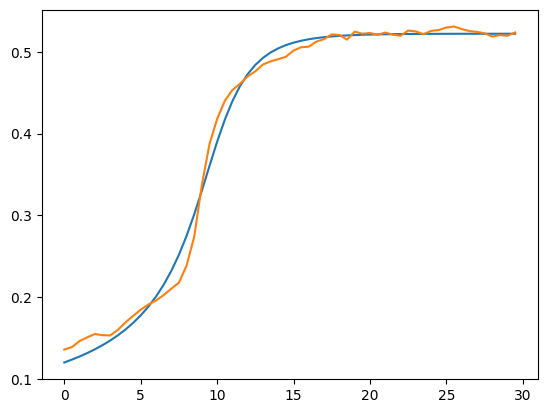

R.S.18 Glycerol_18


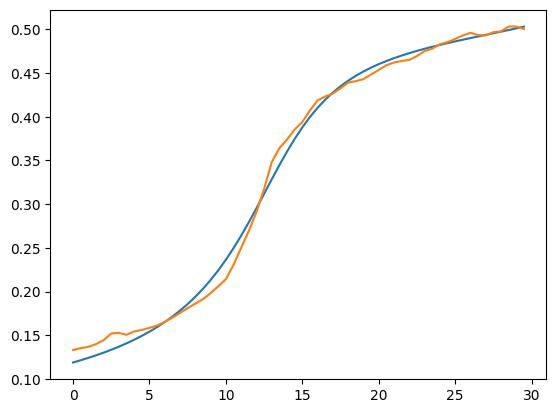

R.S.18 Alpha-D-Glucose_18


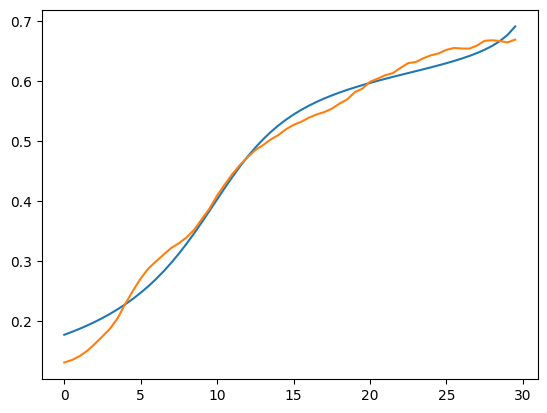

R.S.18 L-Aspartate_18


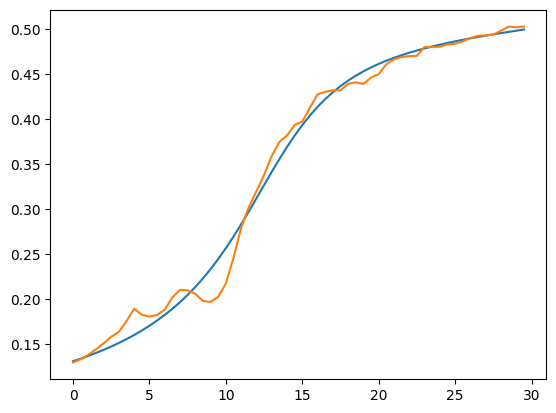

R.S.19 Allantoin_19


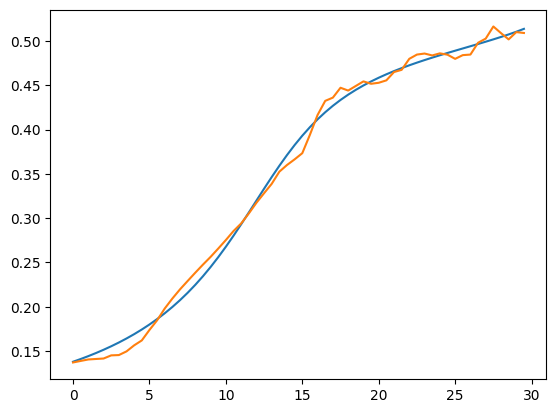

R.S.19 Thymine_19


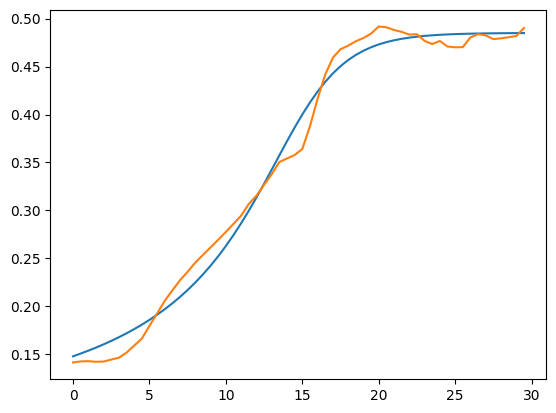

R.S.19 D-Glucose_19


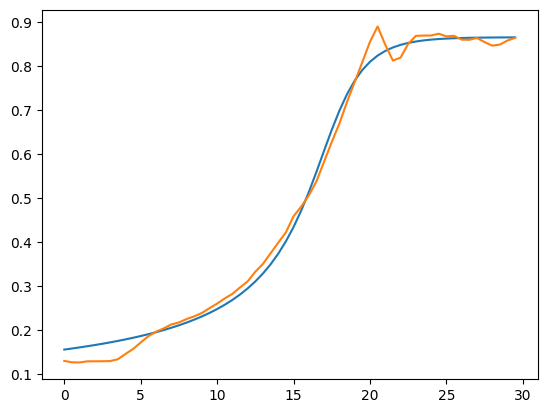

R.S.19 Guanidine_19


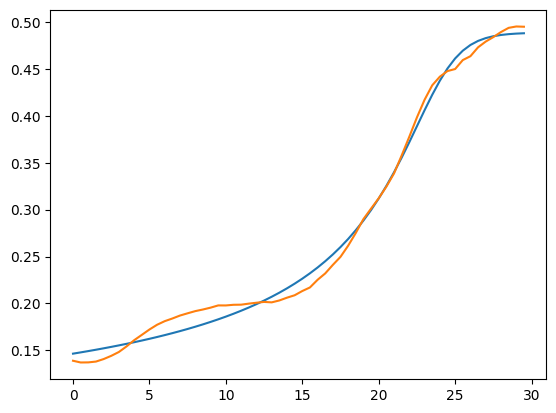

R.S.19 Cytidine_19


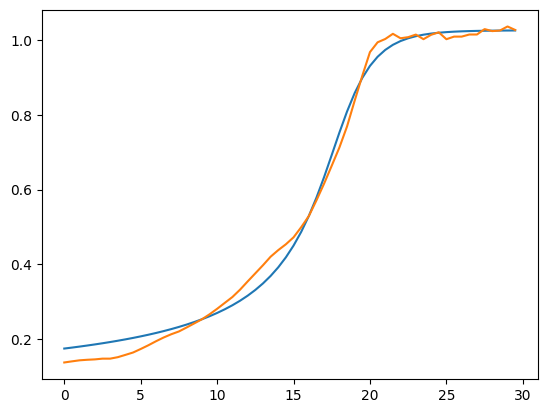

R.S.19 Nitrogen Neg. Control_19


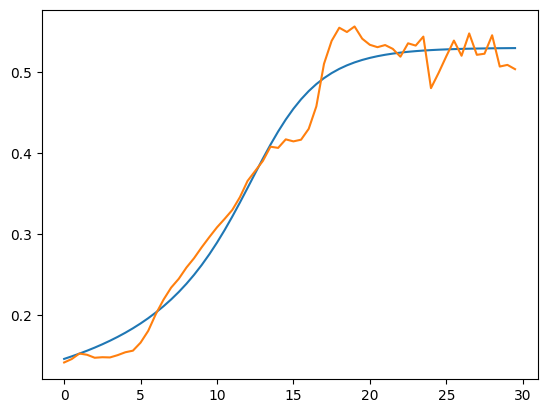

R.S.19 Alpha-D-Glucose_19


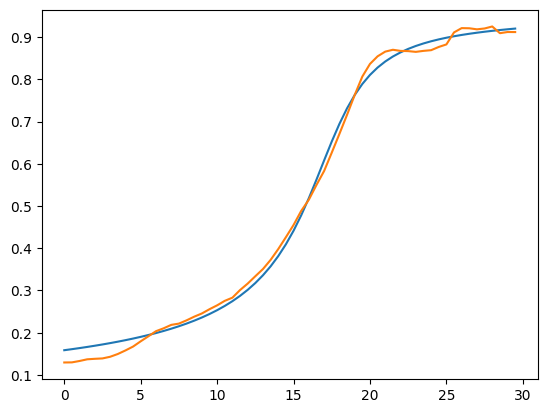

In [36]:
import matplotlib.pyplot as plt

# Plotting B(t) real and predicted
def euler_BMS(model,y0,h,steps,col):
    res=[y0]
    for i in range(steps-1):
        f=model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        res.append(res[-1]+h*f)
    return res

def trap_BMS(model,y0,h,steps,col):
    res=[y0]
    for i in range(steps-1):
        f=model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        y1=res[-1]+h*f
        f1=model.predict({col:pd.DataFrame(data={'B':[y1]})})[col].to_numpy()[0]
        res.append(res[-1]+0.5*h*(f+f1))
    return res

def RK_BMS(model,y0,h,steps,col):
    res=[y0]
    for i in range(steps-1):
        k1 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        k2 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k1/2.]})})[col].to_numpy()[0]
        k3 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k2/2.]})})[col].to_numpy()[0]
        k4 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k3]})})[col].to_numpy()[0]

        # Calculate new x and y
        res.append(res[-1] + 1./6*(k1+2*k2+2*k3+k4))
        """x = x + dx
        f=model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        res.append(res[-1]+h*f)"""
    return res

for col in list(x.keys()) :
    print(col)
    # Integrate ODE with BMS expression
    h=x[col].t[1]-x[col].t[0]
    y0=bms_fulldata_new.x0[str(bms_fulldata_new)][col]
    train_ode_fulldata=RK_BMS(bms_fulldata_new,y0,h,len(y[col]),col)
    plt.plot(x[col].t.to_numpy(),train_ode_fulldata)
    plt.plot(x[col].t.to_numpy(),x[col].B.to_numpy())
    plt.show()

In [30]:
print(bms_fulldata_new.par_values)
print(bms_fulldata_new)
print(bms_fulldata_new.E)
"""
f_name=f'mdl_mod_model2_test.pkl'
file = open(f_name,'wb')
pickle.dump(bms_fulldata_new,file)
file.close()
"""

{'H3': {'_a0_': 64.90637105908664, '_a2_': -2.509459497327416, '_a4_': 6.8098281198783015}, 'D6': {'_a0_': 60.38047937940155, '_a2_': -1.7649855761413533, '_a4_': 4.796319480695242}, 'C7': {'_a0_': 52.667514693499456, '_a2_': -1.5766275066497284, '_a4_': 4.284860244540538}, 'F3': {'_a0_': 26.162522593107912, '_a2_': -1.6790977578159163, '_a4_': 4.557514819689674}, 'B11': {'_a0_': 27.885310153659248, '_a2_': -1.8811505325365805, '_a4_': 5.10227728023857}, 'B12': {'_a0_': 8.54185053263657, '_a2_': -1.0845161900213478, '_a4_': 2.9427899672621156}, 'E12': {'_a0_': 48.992162720192695, '_a2_': -1.8703237065644738, '_a4_': 5.081488251572228}, 'A3': {'_a0_': 43.22570466312554, '_a2_': -1.6682545220713634, '_a4_': 4.533197379407554}, 'G9': {'_a0_': 50.580328015187746, '_a2_': -1.940637224828872, '_a4_': 5.527469821041096}, 'C11': {'_a0_': 47.49782253111648, '_a2_': -1.6183077357383262, '_a4_': 4.397940874011623}, 'D5': {'_a0_': 34.66157874183679, '_a2_': -1.8139971397693844, '_a4_': 4.924244159

"\nf_name=f'mdl_mod_model2_test.pkl'\nfile = open(f_name,'wb')\npickle.dump(bms_fulldata_new,file)\nfile.close()\n"

In [15]:
rows = []
for dataset, params in bms_fulldata_new.par_values.items():
    a0 = params.get("_a0_")
    a2 = params.get("_a2_")
    a4 = params.get("_a4_")
    a1 = params.get("_a1_")

    row = {
        "Dataset": dataset,
        "r": a0,
        "c1":a2,
        "c2":a4,
    }
    rows.append(row)

# Save to CSV
df = pd.DataFrame(rows)
display(df)
df.to_csv("model2_mod_parameters_test.csv", index=False)

,Dataset,r,c1,c2
0,B5,33.413286,-1.599515,4.344873
1,A8,28.346295,-2.016661,5.462349
2,G7,66.377809,-1.513042,4.112558
3,A9,34.930560,-1.952555,5.298242
4,F7,39.920338,-1.644525,4.468268
...,...,...,...,...
61,R.S.19 L-Pyro-Glutamate.1_19,9.653011,-1.091170,2.975731
62,R.S.19 Thiourea_19,13.511921,-1.622572,4.411707
63,R.S.19 L-Glutathione_19,8.628439,-1.045601,2.861630
64,R.S.19 Histamine_19,12.726853,-1.214650,3.302912
